# Training report

Charts every column of a run's `progress.csv`, epoch by epoch.

**Point `RUN` at a run directory (or straight at a `progress.csv`) and run all.**

One caveat worth reading before you interpret anything here (see
`notes/training.md`): with the curriculum on, the world changes underneath the
policy, so **a falling `lifespan_mean` in this file may be a worse worm or a
harder world.** The `lifespan / freeze baseline` panel corrects for the
metabolism but not for food density or radii. To actually establish that the
policy improved, evaluate checkpoints on a fixed world.

In [1]:
# ── point this at a run ──────────────────────────────────────────────────────
RUN = "experiments/ppo_s0_1"   # a run directory, or a path to a progress.csv
SMOOTH = 15                    # rolling-mean window in epochs; 1 disables smoothing

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Resolve RUN against the repo root, so the notebook works whether it is run
# from the project root or from notebooks/.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))  # so `from envs import ...` works in added cells

path = Path(RUN)
if not path.is_absolute() and not path.exists():
    path = ROOT / RUN
csv_path = path if path.suffix == ".csv" else path / "progress.csv"
run_dir = csv_path.parent
df = pd.read_csv(csv_path)

# The env config sits beside the csv, and supplies the one number that makes
# lifespan interpretable: what the worm would score eating nothing at all.
env_yaml = run_dir / "env.yaml"
env_cfg = yaml.safe_load(env_yaml.read_text()) if env_yaml.exists() else None

if env_cfg and "basal_cost" in df:
    initial_energy = env_cfg["metabolism"]["initial_energy"]
    # Moves with the curriculum, so it is a per-epoch series, not a constant.
    df["freeze_baseline"] = initial_energy / df["basal_cost"]
    df["lifespan_ratio"] = df["lifespan_mean"] / df["freeze_baseline"]

if {"lifespan_std", "lifespan_mean"} <= set(df.columns):
    # Spread of outcomes. PPO learns from differences between episodes, so if
    # this is ~0 there is nothing to learn from at any number of steps.
    df["lifespan_cv"] = df["lifespan_std"] / df["lifespan_mean"]

print(f"{csv_path}")
print(f"{len(df)} epochs, {df['total_steps'].iloc[-1]:,} env steps"
      + (f", {df['elapsed_s'].iloc[-1] / 3600:.1f} h wall clock" if "elapsed_s" in df else ""))
print(f"\ncolumns: {', '.join(df.columns)}")

/Users/ocdbytes/Desktop/ML/ai-worm/experiments/ppo_s0_1/progress.csv
500 epochs, 4,000,000 env steps, 0.2 h wall clock

columns: elapsed_s, epoch, total_steps, curriculum, food_count, eat_radius, scent_radius, basal_cost, episodes, lifespan_mean, lifespan_std, lifespan_min, lifespan_max, return_mean, eaten_mean, mean_abs_action, energy_in, energy_out, distance_per_energy, death_rate, loss_pi, loss_v, delta_loss_v, stop_iter, value_mean, log_std, kl, entropy, clip_frac, surrogate, freeze_baseline, lifespan_ratio, lifespan_cv


In [3]:
# Recessive chrome, one accent. Colours are the validated categorical slots 1-3,
# which is as many series as any panel here uses.
INK, INK_SOFT, GRID_C, RAW_C = "#0b0b0b", "#52514e", "#e3e2df", "#c3c2bd"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID_C, "axes.labelcolor": INK_SOFT, "text.color": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.grid": True, "grid.color": GRID_C, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "figure.dpi": 110, "legend.fontsize": 7,
})


def smooth(series):
    if SMOOTH <= 1:
        return series
    return series.rolling(SMOOTH, min_periods=1, center=True).mean()


def panel(ax, column, title, hline=None, overlay=None, overlay_label=None, color=SERIES[0]):
    """One metric against epoch.

    Raw stays on the page but recessive; the smoothed line is the one to read.
    Never a second y-scale on the same axes - an overlay is only allowed when it
    shares the metric's units (e.g. a baseline in the same 'steps').
    """
    if column not in df.columns:
        ax.set_axis_off()
        ax.text(0.5, 0.5, f"{column}\nnot logged in this run",
                ha="center", va="center", color=INK_SOFT, fontsize=8)
        return

    ax.plot(df["epoch"], df[column], color=RAW_C, lw=0.8, zorder=1, label="per epoch")
    ax.plot(df["epoch"], smooth(df[column]), color=color, lw=2, zorder=3,
            label=f"{SMOOTH}-epoch mean" if SMOOTH > 1 else "value")

    if overlay is not None and overlay in df.columns:
        ax.plot(df["epoch"], df[overlay], color=INK_SOFT, lw=1.4, ls="--", zorder=2,
                label=overlay_label or overlay)
    if hline is not None:
        ax.axhline(hline, color=INK_SOFT, lw=1.4, ls="--", zorder=2,
                   label=f"{hline:g}")

    ax.set_title(title, loc="left", color=INK)
    ax.margins(x=0.01)
    if len(ax.get_lines()) > 1:
        ax.legend(frameon=False, loc="best")


def grid(specs, ncols=2, height=2.6):
    """Lay panels out in a grid. Each metric gets its own axes - two measures of
    different scale are never forced onto one."""
    nrows = -(-len(specs) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, height * nrows))
    for ax, spec in zip(np.ravel(np.atleast_1d(axes)), specs):
        panel(ax, **spec)
    for ax in np.ravel(np.atleast_1d(axes))[len(specs):]:
        ax.set_axis_off()
    for ax in np.ravel(np.atleast_1d(axes))[-ncols:]:
        ax.set_xlabel("epoch")
    fig.tight_layout()
    return fig

## 1. Did it learn?

`lifespan_mean` is the return under a `+1`/step reward. The dashed line is what
the worm would have scored eating **nothing** — beating it is the actual bar,
and it moves as the curriculum tightens the metabolism.

`lifespan / freeze baseline` is that comparison as a ratio: **1.0 means it may
as well have frozen**, 2.0 means it doubled its life by eating.

`lifespan_cv` is the spread of outcomes. Below ~0.05 every episode returns the
same number, every advantage is critic noise, and more steps will not help.

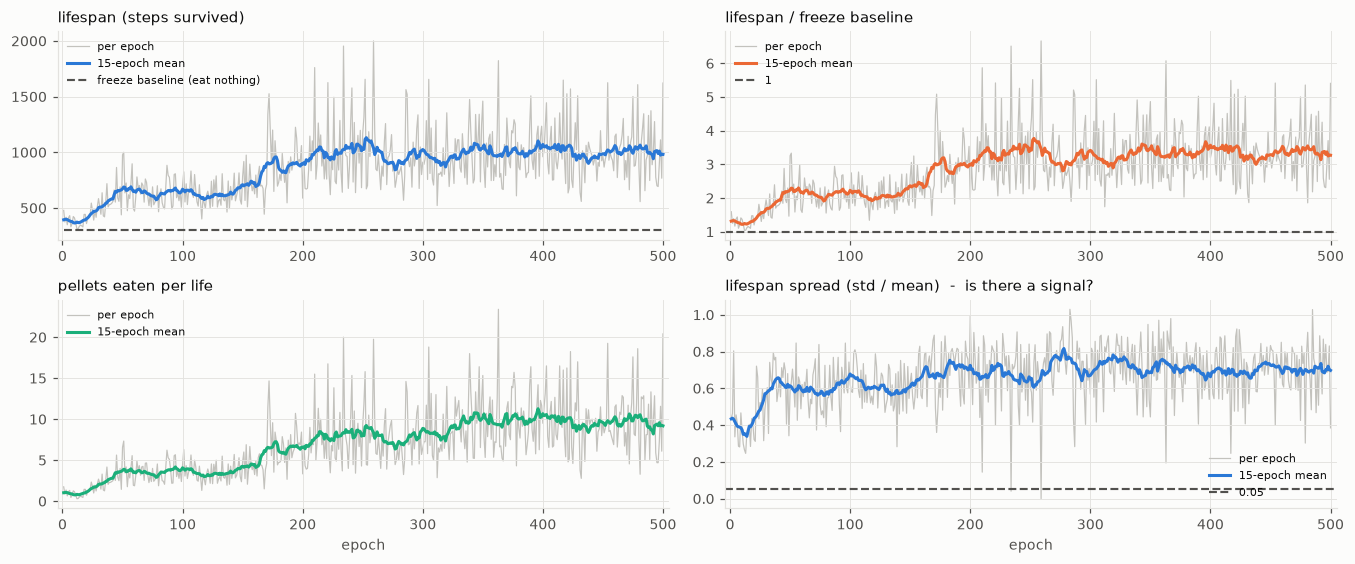

In [4]:
grid([
    {"column": "lifespan_mean", "title": "lifespan (steps survived)",
         "overlay": "freeze_baseline", "overlay_label": "freeze baseline (eat nothing)"},
    {"column": "lifespan_ratio", "title": "lifespan / freeze baseline", "hline": 1.0,
         "color": SERIES[1]},
    {"column": "eaten_mean", "title": "pellets eaten per life", "color": SERIES[2]},
    {"column": "lifespan_cv", "title": "lifespan spread (std / mean)  -  is there a signal?",
         "hline": 0.05},
]);

## 2. The world it was learning in

The curriculum. Every one of these getting harder at once is why the lifespan
chart above cannot be read on its own.

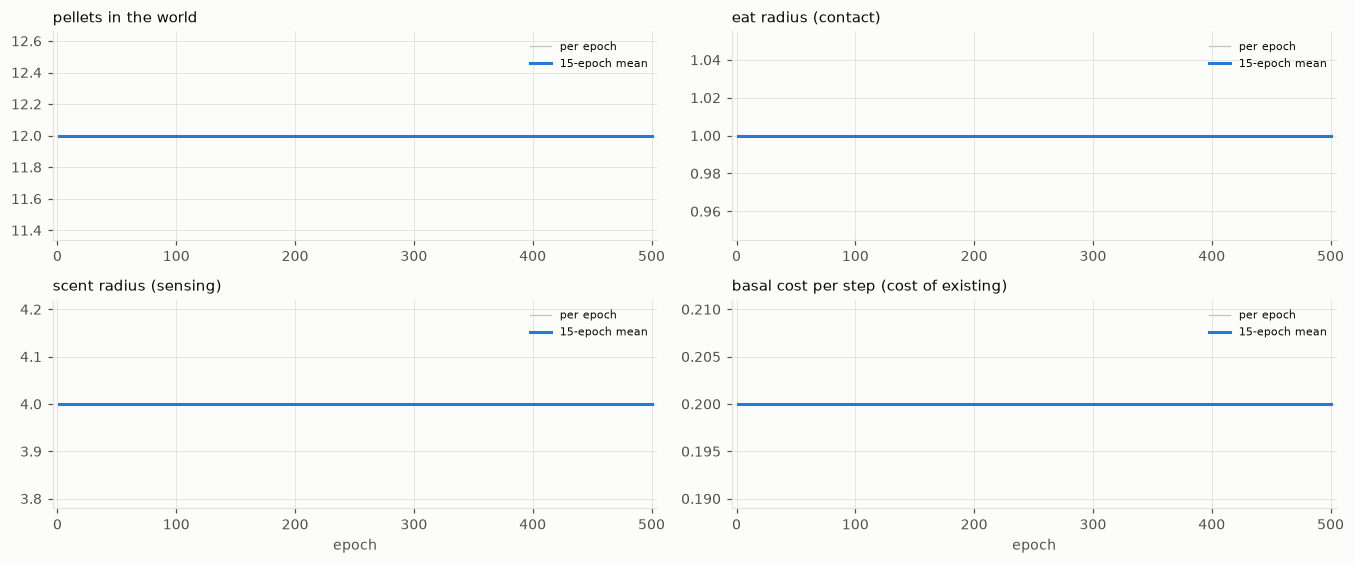

In [5]:
grid([
    {"column": "food_count", "title": "pellets in the world"},
    {"column": "eat_radius", "title": "eat radius (contact)"},
    {"column": "scent_radius", "title": "scent radius (sensing)"},
    {"column": "basal_cost", "title": "basal cost per step (cost of existing)"},
]);

## 3. Exploration and behaviour

`entropy` is `sum(log_std)` plus a constant — the two are the same curve. Falling
toward zero means the policy is going deterministic and has stopped discovering.

`mean_abs_action` is the freeze-trap detector: decaying toward zero while
lifespan sits at the baseline means the worm has learned to stand still.

`death_rate` below 1.0 means episodes are hitting the step cap rather than dying.

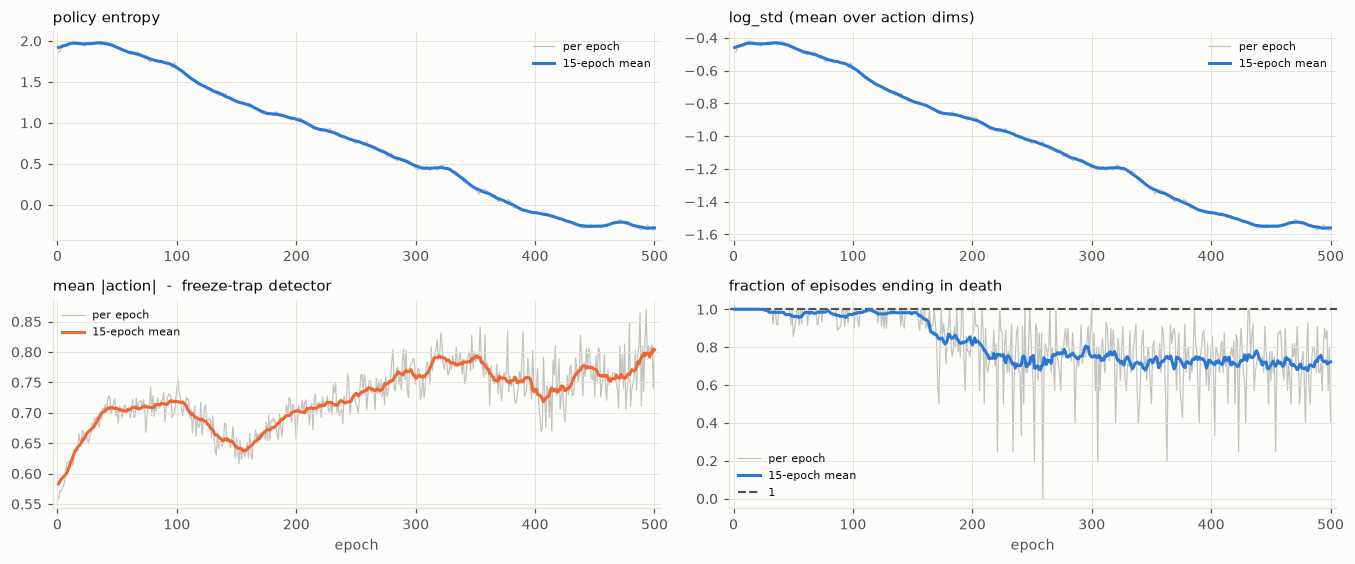

In [6]:
grid([
    {"column": "entropy", "title": "policy entropy"},
    {"column": "log_std", "title": "log_std (mean over action dims)"},
    {"column": "mean_abs_action", "title": "mean |action|  -  freeze-trap detector",
         "color": SERIES[1]},
    {"column": "death_rate", "title": "fraction of episodes ending in death", "hline": 1.0},
]);

## 4. The PPO update

`stop_iter` pinned low means each update moves further than the collected data
supports (drop `policy_lr`); pinned at `policy_iters` means the KL guard never
fires and the steps are tiny (raise it).

`kl` is unbiased but high-variance and can come out negative — that is an
estimator artefact, not a bug.

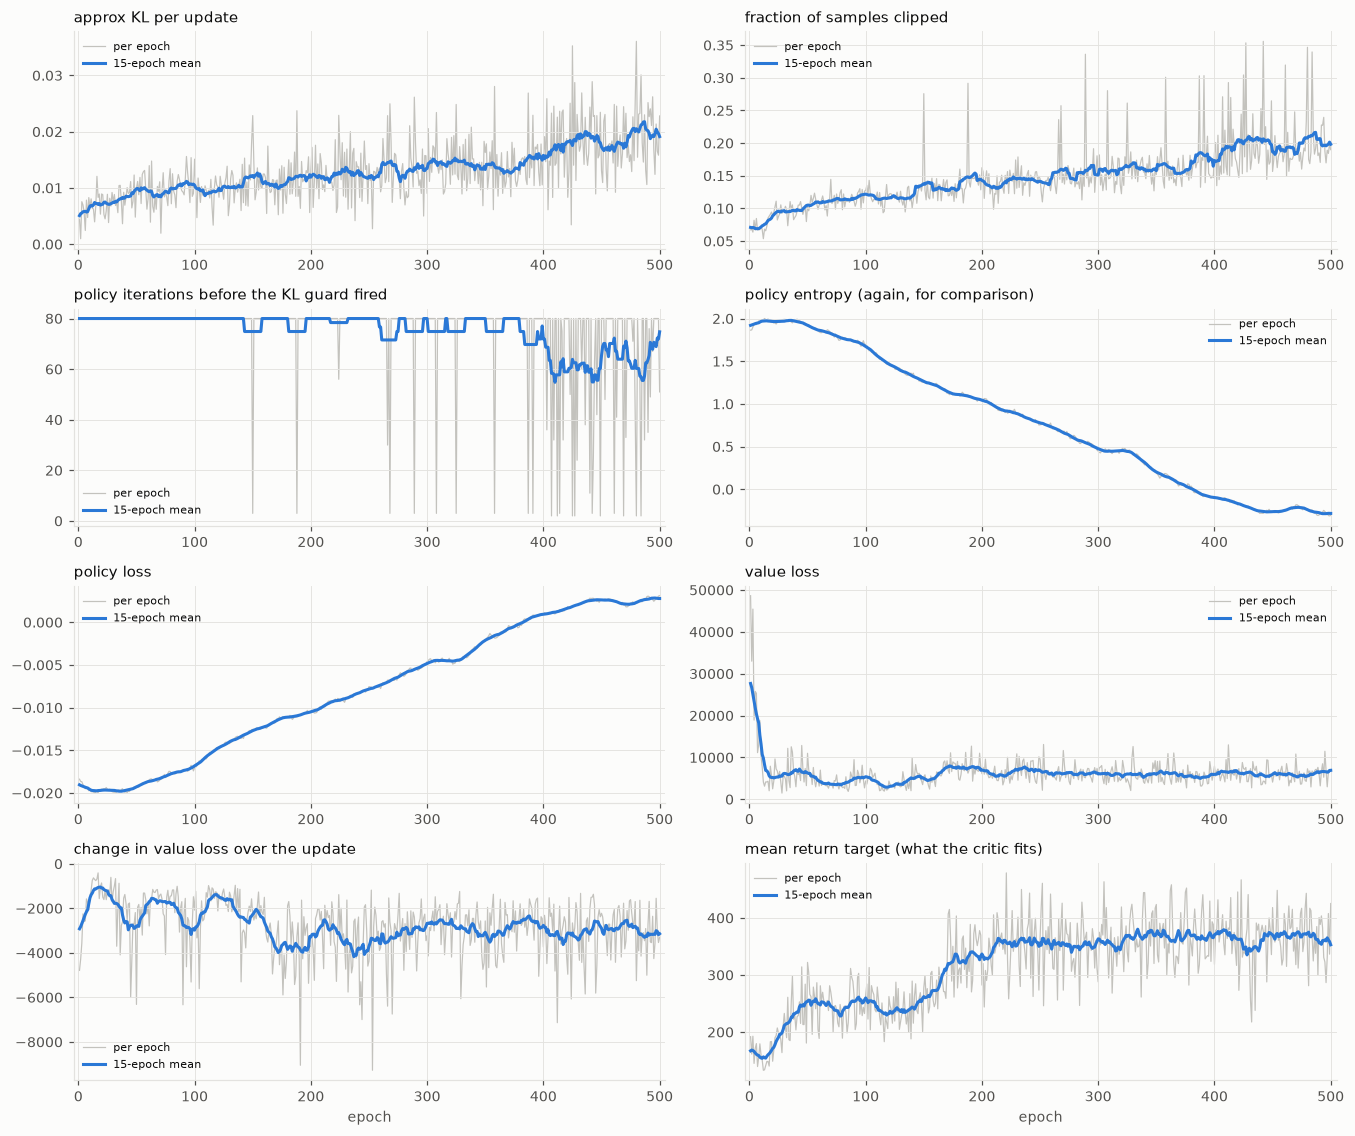

In [7]:
grid([
    {"column": "kl", "title": "approx KL per update"},
    {"column": "clip_frac", "title": "fraction of samples clipped"},
    {"column": "stop_iter", "title": "policy iterations before the KL guard fired"},
    {"column": "entropy", "title": "policy entropy (again, for comparison)"},
    {"column": "loss_pi", "title": "policy loss"},
    {"column": "loss_v", "title": "value loss"},
    {"column": "delta_loss_v", "title": "change in value loss over the update"},
    {"column": "value_mean", "title": "mean return target (what the critic fits)"},
]);

## 5. Everything else

Any numeric column not already plotted, so nothing in the file goes unseen.

10 further columns: curriculum, episodes, lifespan_std, lifespan_min, lifespan_max, return_mean, energy_in, energy_out, distance_per_energy, surrogate


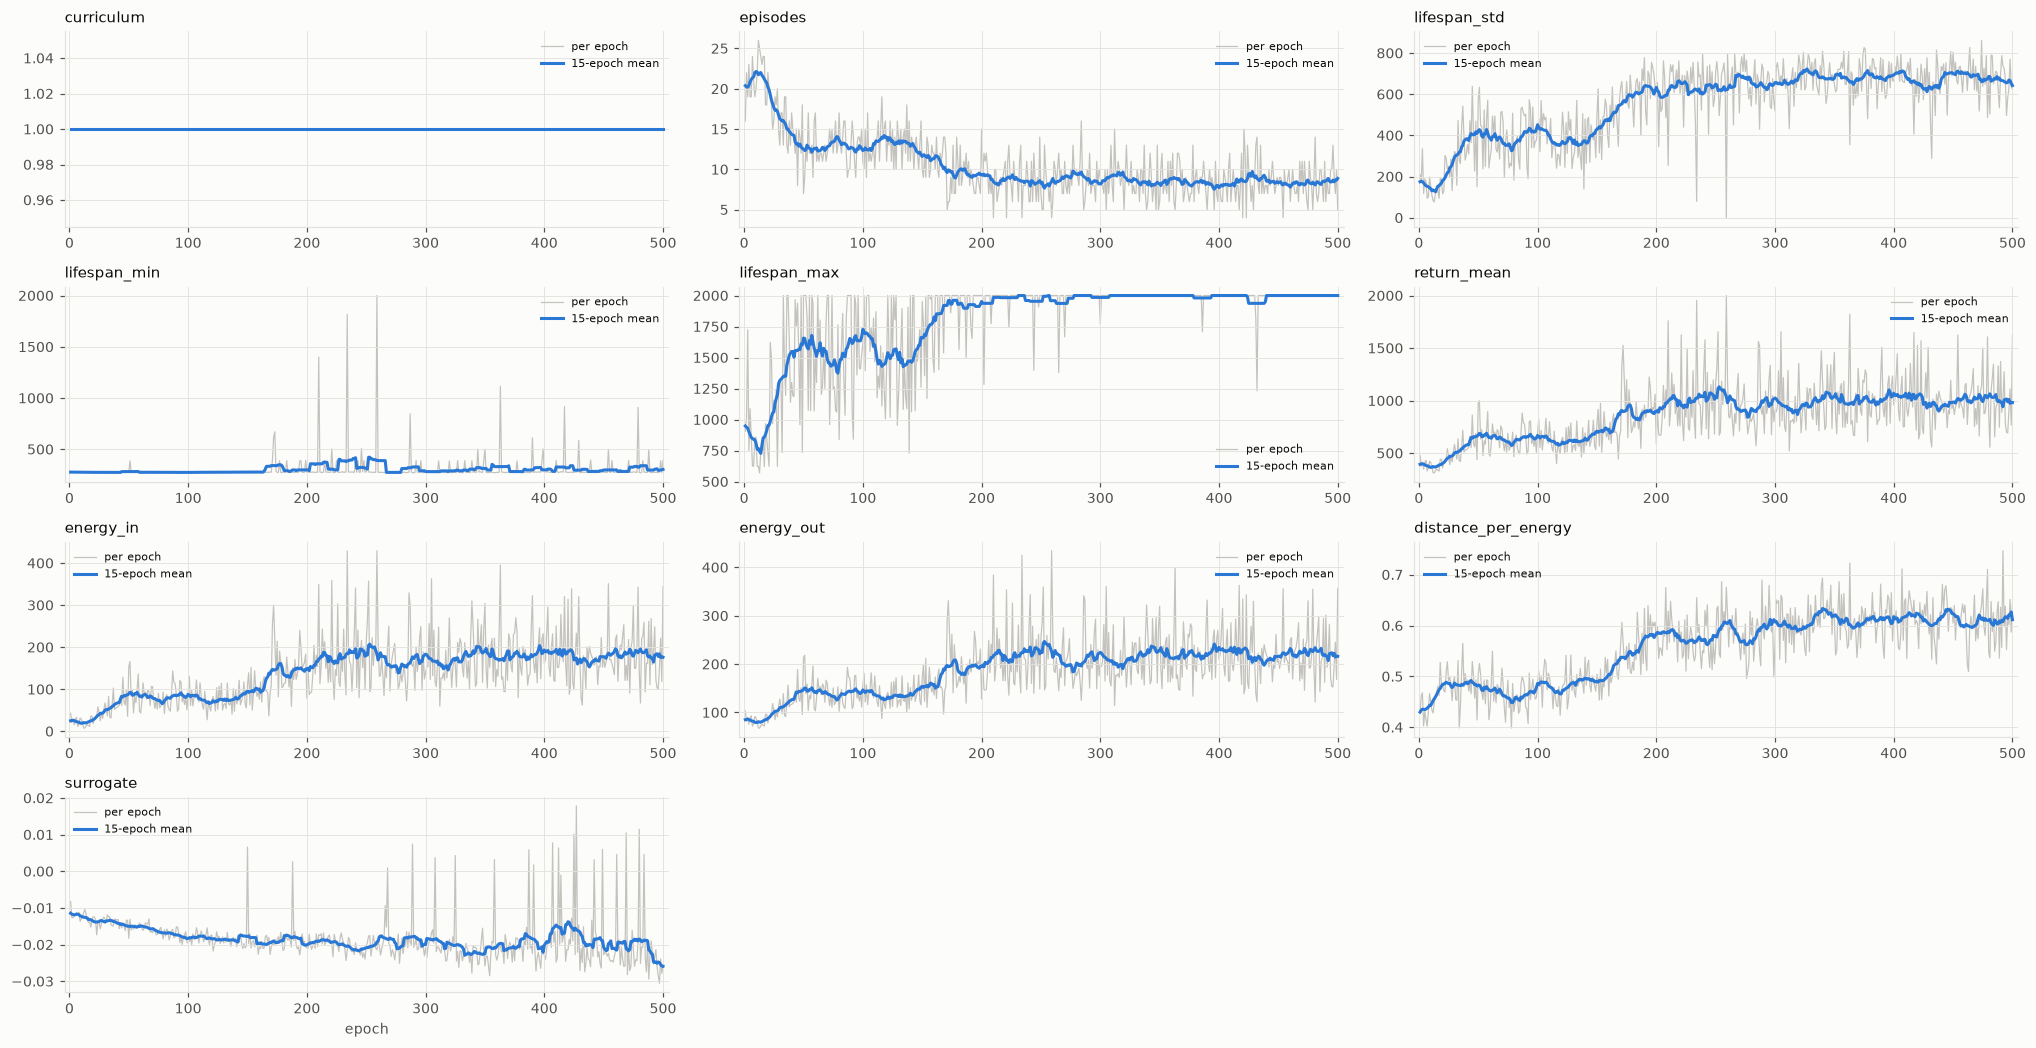

In [8]:
shown = {
    "epoch", "total_steps", "elapsed_s", "freeze_baseline",
    "lifespan_mean", "lifespan_ratio", "eaten_mean", "lifespan_cv",
    "food_count", "eat_radius", "scent_radius", "basal_cost",
    "entropy", "log_std", "mean_abs_action", "death_rate",
    "kl", "clip_frac", "stop_iter", "loss_pi", "loss_v", "delta_loss_v", "value_mean",
}
rest = [c for c in df.columns
        if c not in shown and pd.api.types.is_numeric_dtype(df[c])]
print(f"{len(rest)} further columns: {', '.join(rest) if rest else '(none)'}")
if rest:
    grid([{"column": c, "title": c} for c in rest], ncols=3, height=2.4);

## 6. Throughput

Sanity checks rather than results. Fewer than ~5 episodes per epoch makes every
episode statistic above mostly noise — raise `steps_per_epoch`.

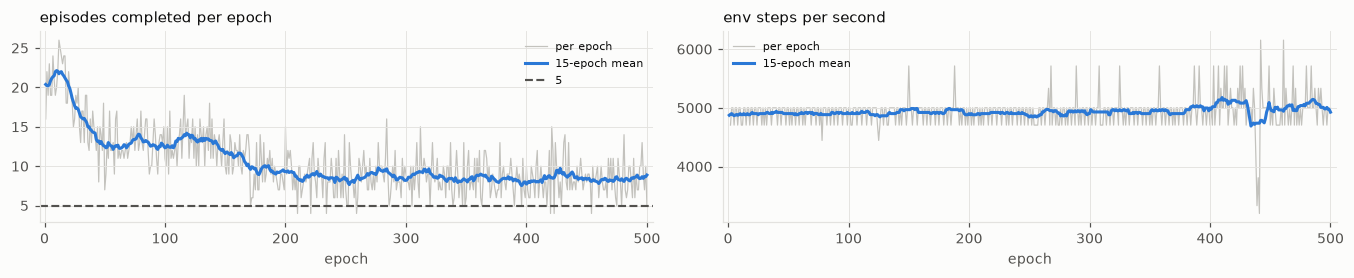

In [9]:
if "elapsed_s" in df.columns:
    df["steps_per_sec"] = df["total_steps"].diff() / df["elapsed_s"].diff()

grid([
    {"column": "episodes", "title": "episodes completed per epoch", "hline": 5},
    {"column": "steps_per_sec", "title": "env steps per second"},
]);